# CUWALID TRAINING

## CUWALID: Python basics - Raster data

To help you understand the model, it is useful to force the model with datasets that are simple to interpret.

Here you will find a set of functions that can help you to create synthetic raster datasets that can be used for model testing. DRYP uses *.ASC and *.tif as raster data for model parameters.

Below you can find a set of examples of synthetic datasets:
1. Create raster files of model paramters
2. Create synthetic raster files of constant head boundary conditions

This notebook will help you to create **test** raster files to prepare test models for DRYP

In [1]:
import sys
#sys.modules[_name_]._dict_clear()
import os
import numpy as np
from landlab import RasterModelGrid
from landlab.io import read_esri_ascii
from landlab.io import write_esri_ascii

In [2]:
import matplotlib.pyplot as plt

In [3]:
def lakes_surface(n=200, scale=10, offset=0):
    # Make the X, Y meshgrid instead of np.tile
    x = np.linspace(-2*np.pi, 2*np.pi, n)
    y = np.linspace(-2*np.pi, 2*np.pi, n)
    xs, ys = np.meshgrid(x, y) 
    # Z evaluation
    amp = (np.sin(xs)+np.cos(ys))*0.5
    #amp[amp > 0.5] = 1
    #amp[amp <= 0.5] = 0
    amp = amp*scale + offset    
    return amp

def lakes_long_surface(n=200, scale=10, offset=0):
    # Make the X, Y meshgrid instead of np.tile
    x = np.linspace(-0*np.pi, 2*np.pi, n)
    y = np.linspace(-0*np.pi, 2*np.pi, n)
    xs, ys = np.meshgrid(x, y) 
    # Z evaluation
    amp = (np.sin(xs+ys*0))*0.5
    #amp[amp > 0.5] = 1
    #amp[amp <= 0.5] = 0
    amp = amp*scale + offset    
    return amp
def lakes_dlong_surface(n=200, scale=10, offset=0):
    # Make the X, Y meshgrid instead of np.tile
    x = np.linspace(-0.5*np.pi, 1.5*np.pi, n)
    y = np.linspace(-0.*np.pi, 1.5*np.pi, n)
    xs, ys = np.meshgrid(x, y) 
    # Z evaluation
    amp = (np.sin(xs+ys)+np.cos(ys))*0.5
    #amp[amp > 0.5] = 1
    #amp[amp <= 0.5] = 0
    amp = amp*scale + offset    
    return amp
def add_slope(array, slopex=1.0, slopey=1.0):
    n=np.shape(array)[0]
    x = np.linspace(0, n, n)
    xs, ys = np.meshgrid(x, x)
    array = array+(xs*slopex+ys*slopey)*0.5
    return array

def lakes_vshape(nx=21, ny=3, scale=10, offset=0, slope=0.5):
    # Make the X, Y meshgrid instead of np.tile
    x = np.linspace(0, nx-1, nx)
    y = np.linspace(1, 1, ny)
    xs, ys = np.meshgrid(x, y)
    #print(xs, ys)
    # Z evaluation
    amp = (nx//2 - xs)*slope
    #print(amp)
    #print((xs[:, nx//2:]-nx//2))#*slope)
    amp[:, nx//2:] = (xs[:, nx//2:]-nx//2)*slope
    #amp[amp > 0.5] = 1
    #amp[amp <= 0.5] = 0
    amp = amp*scale + offset    
    return amp

In [4]:
def plot_surface(b):
    fig, ax = plt.subplots()
    im = plt.imshow(b)
    plt.contour(b, colors="k")
    fig.colorbar(im)
    
def plot_profile(dem, bathymetry=None, rows=15):	
	fig, ax = plt.subplots()#3, 5, sharex=True, sharey=True)
	#fig.set_size_inches(10., 7.2)
	for irow in rows:
		ax.plot(dem[irow], 'k')
		if bathymetry is not None:
			ax.plot(dem[irow]-bathymetry[irow], 'r')

In [5]:
def save_raster(array, path_output, dx=1000):
    row, col =np.shape(array)
    rg = RasterModelGrid((row, col), dx)
    rg.at_node.clear() 
    #rg,at_node["var"]
    rg.add_field("var", array, at="node")
    #out_filename_sigma_ks = filename_out+'_sigma_ks.txt'
    os.remove(path_output) if os.path.exists(path_output) else None
    files = write_esri_ascii(path_output, rg,'var')
    pass

### Create a raster grid for lakes

Create a topographical surface with depresions representing lakes

In [6]:
#b = lakes_surface(n=30, scale=100, offset=200)
#b = lakes_long_surface(n=30, scale=100, offset=200)
b = lakes_dlong_surface(n=30, scale=100, offset=200)

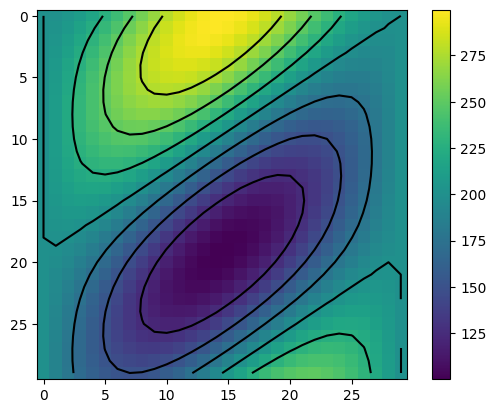

In [7]:
plot_surface(b)

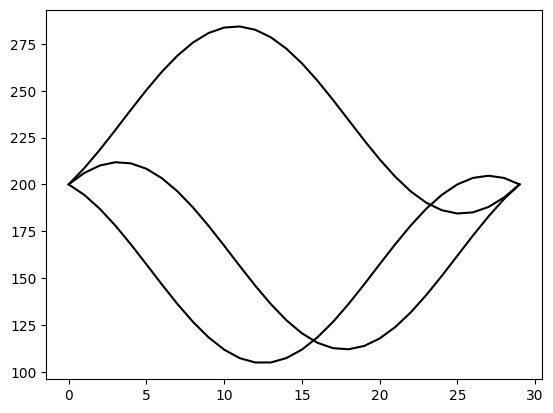

In [8]:
plot_profile(b, bathymetry=None, rows=[5, 15, 22])

#### Surface with lakes

Here you can create a surface elevation which will allows to include lakes in the model. Basically, you will flatten the lake are to latter add lake bathymetry. 

In [9]:
slopex = 2.0
slopey = 0.0
max_water_level = 160

In [10]:
surface = b.copy()
#surface[surface < 200] = 200
surface = add_slope(surface, slopex=slopex, slopey=slopey)
surface[surface < max_water_level] = max_water_level


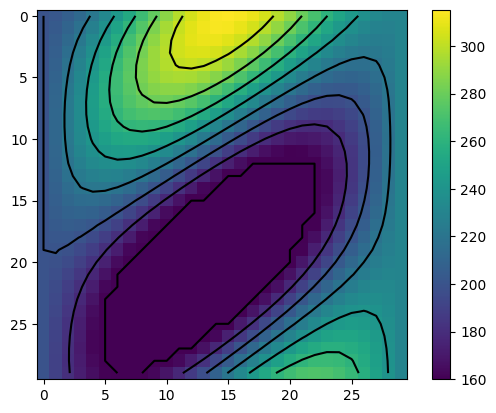

In [11]:
plot_surface(surface)

#### Lakes bathymetry

Create a lake bathymetry for running a test sample model

In [12]:
#bathymetry = 200 - b
bathymetry = max_water_level - add_slope(b, slopex=slopex, slopey=slopey)
bathymetry[bathymetry < 0] = 0.0

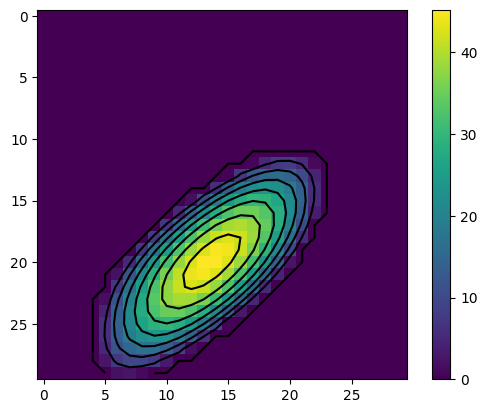

In [13]:
plot_surface(bathymetry)

##### plot profile

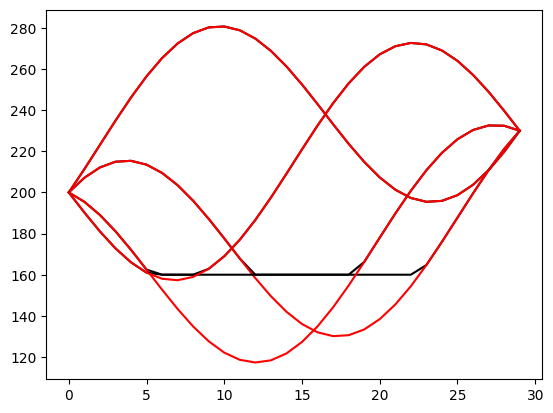

In [14]:
#plot_profile(surface, bathymetry=None, rows=[15, 22, 20])
plot_profile(surface, bathymetry=bathymetry, rows=[7, 15, 22, 29])
#plot_profile(b, bathymetry=None, rows=[15, 22])

#### Create an initial water table

Create a raster file representing inital condition for the water table

In [15]:
depth = 120
watertable = add_slope(b*0+depth, slopex=slopex, slopey=slopey)

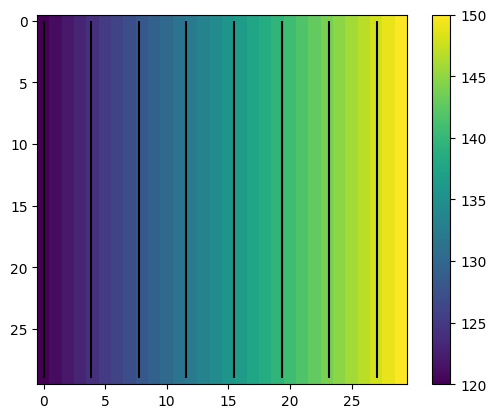

In [16]:
plot_surface(watertable)

#### Consatant head boundary

Create a constant head boundary condition file for running DRYP

In [17]:
chb = b*0-9999.0
chb[:,0] = depth

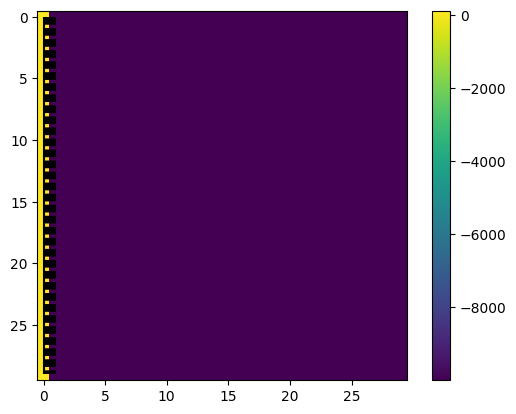

In [18]:
plot_surface(chb)

## Save raster files

Here, you can use this section to store raster dataset in you PC

In [19]:
folder = "C:/Users/Edisson/Documents/GitHub/CUWALID-Example/Examples/Python/"

In [20]:
fname = folder + "/mlakes_dem.asc"
save_raster(surface, fname, dx=1000.0)

C:\Users\Edisson\.conda\envs\tdryp\Lib\site-packages\landlab\graph\graph.py:403: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return self.ds.dims["node"]
C:\Users\Edisson\.conda\envs\tdryp\Lib\site-packages\landlab\graph\graph.py:490: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return self.ds.dims["link"]
C:\Users\Edisson\.conda\envs\tdryp\Lib\site-packages\landlab\graph\graph.py:869: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names

In [21]:
fname = folder + "/mlakes_bathymetry.asc"
save_raster(bathymetry, fname, dx=1000.0)

In [22]:
fname = folder + "/mlakes_watertable.asc"
save_raster(watertable, fname, dx=1000.0)

In [23]:
fname = folder + "/mlakes_constant_head.asc"
save_raster(chb, fname, dx=1000.0)

### create a v shape 1-d model for testing

In [88]:
nx=21
ny=3
mask = np.zeros([ny, nx])
mask[1, 1:-1] = 1
vlake = lakes_vshape(nx=nx, ny=ny, scale=2, offset=90, slope=0.5)
vbathymetry = 95 - vlake
vlake[vlake < 95] = 95
vbathymetry[vbathymetry < 0] = 0
vbathymetry = vbathymetry * mask
vCHB = vlake*0-9999
vCHB[:, 0] = 90
vCHB[:, -1] = 90
vhead = vlake*0+90


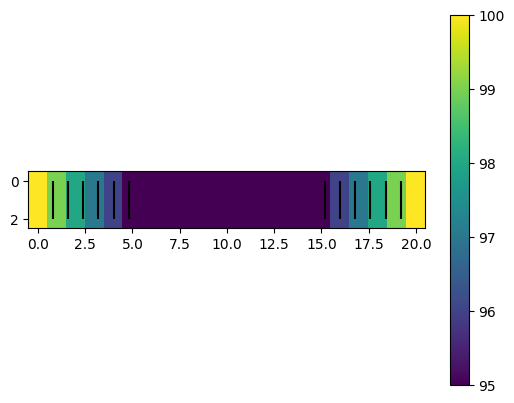

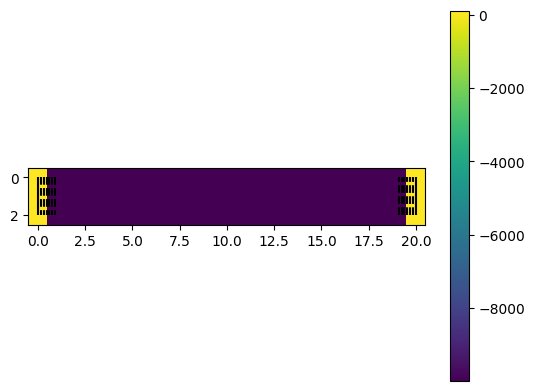

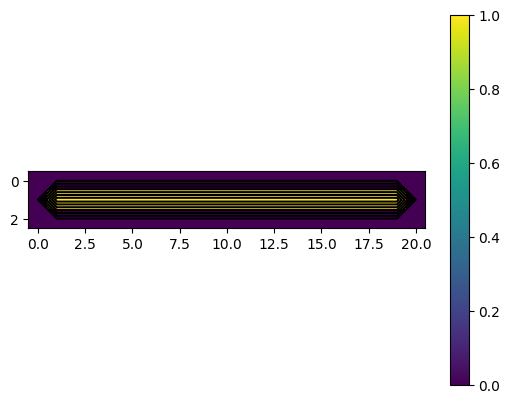

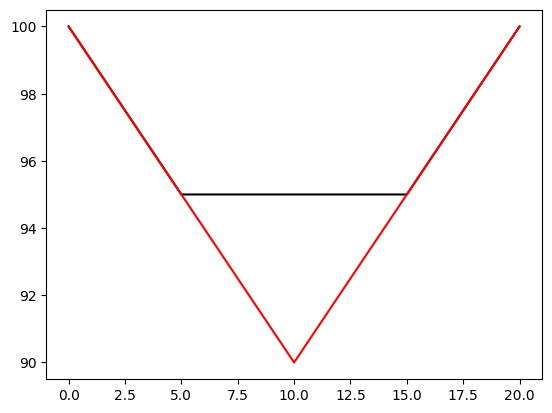

In [89]:
plot_surface(vlake)
plot_surface(vCHB)
plot_surface(mask)
plot_profile(vlake, bathymetry=vbathymetry, rows=[1])

In [90]:
folder = "C:/Users/km19051/OneDrive - University of Bristol/Documents/testing/vlake1d/input"
fname = folder + "/vlakes_dem.asc"
save_raster(vlake, fname, dx=1000.0)
fname = folder + "/vlakes_bathymetry.asc"
save_raster(vbathymetry, fname, dx=1000.0)
fname = folder + "/vlakes_watertable.asc"
save_raster(vhead, fname, dx=1000.0)
fname = folder + "/vlakes_constant_head.asc"
save_raster(vCHB, fname, dx=1000.0)
fname = folder + "/vlakes_mask.asc"
save_raster(mask, fname, dx=1000.0)

C:\Users\km19051\AppData\Local\Temp\ipykernel_25984\1963325220.py:3: DeprecationWarning: landlab.io.write_esri_ascii has been deprecated, use landlab.io.esri_ascii.dump instead
  save_raster(vlake, fname, dx=1000.0)
C:\Users\km19051\AppData\Local\Temp\ipykernel_25984\1963325220.py:5: DeprecationWarning: landlab.io.write_esri_ascii has been deprecated, use landlab.io.esri_ascii.dump instead
  save_raster(vbathymetry, fname, dx=1000.0)
C:\Users\km19051\AppData\Local\Temp\ipykernel_25984\1963325220.py:7: DeprecationWarning: landlab.io.write_esri_ascii has been deprecated, use landlab.io.esri_ascii.dump instead
  save_raster(vhead, fname, dx=1000.0)
C:\Users\km19051\AppData\Local\Temp\ipykernel_25984\1963325220.py:9: DeprecationWarning: landlab.io.write_esri_ascii has been deprecated, use landlab.io.esri_ascii.dump instead
  save_raster(vCHB, fname, dx=1000.0)
C:\Users\km19051\AppData\Local\Temp\ipykernel_25984\1963325220.py:11: DeprecationWarning: landlab.io.write_esri_ascii has been depr

## create initial condition lakes

In [13]:
nx=31
ny=31
mask = np.zeros([ny, nx])
mask[1, 1:-1] = 1
vlake = lakes_vshape(nx=nx, ny=ny, scale=2, offset=90, slope=0.5)
vbathymetry = 95 - vlake
vlake[vlake < 95] = 95
vbathymetry[vbathymetry < 0] = 0
vbathymetry = vbathymetry * mask
vCHB = vlake*0-9999
vCHB[:, 0] = 83
#vCHB[:, -1] = 85
vhead = vlake*0+85


In [14]:
folder = "C:/Users/km19051/OneDrive - University of Bristol/Documents/testing/reservoir/input"
fname = folder + "/vlakes_dem.asc"
#save_raster(vlake, fname, dx=1000.0)
#fname = folder + "/vlakes_bathymetry.asc"
#save_raster(vbathymetry, fname, dx=1000.0)
fname = folder + "/LA_wte_ini.asc"
save_raster(vhead, fname, dx=1000.0)
fname = folder + "/LA_CHB.asc"
save_raster(vCHB, fname, dx=1000.0)
#fname = folder + "/vlakes_mask.asc"
#save_raster(mask, fname, dx=1000.0)

C:\Users\km19051\AppData\Local\Temp\ipykernel_23220\284074348.py:7: DeprecationWarning: landlab.io.write_esri_ascii has been deprecated, use landlab.io.esri_ascii.dump instead
  save_raster(vhead, fname, dx=1000.0)
C:\Users\km19051\AppData\Local\Temp\ipykernel_23220\284074348.py:9: DeprecationWarning: landlab.io.write_esri_ascii has been deprecated, use landlab.io.esri_ascii.dump instead
  save_raster(vCHB, fname, dx=1000.0)


# Create model files for bechmarking lakes

In [13]:
import rasterio
from rasterio.transform import from_origin

def save_array_as_raster(array, filename, dx=1000):
    """
    Save a 2D array as a raster file.
    
    Parameters:
    - array: 2D numpy array to save as raster.
    - filename: Output filename for the raster file.
    - width: Width of the raster.
    - height: Height of the raster.
    """
    # Get the shape of the array
    height, width = array.shape

    # Define the transform for the raster
    transform = from_origin(0, 0, dx, -dx)  # lower left corner at (0,0) with pixel size of dx
    
    # Save the array as a raster file
    with rasterio.open(filename, 'w', driver='AAIGrid', height=height, width=width,
                       count=1, dtype=array.dtype, crs='EPSG:4326', transform=transform) as dst:
        dst.write(array, 1
        )


In [185]:
nx=17
ny=19
top_elevation = 200.0
mask = np.zeros([ny, nx])
mask[1:-1, 1:-1] = 1

dem = np.ones([ny, nx])*top_elevation
bathymetry = np.zeros([ny, nx])
bathymetry[7:12,6:11] = top_elevation - 100
bathymetry[8:11,7:10] = top_elevation - 90

noksat = np.ones([ny, nx])*1.0
ksat = np.ones([ny, nx])*1.0

ksat[7:12,6:11] = 4.0

CHB = dem*0-9999
CHB[:, 0] = 160
CHB[:, -1] = 120

wte = dem*0+110

aqtype = mask*0 + 1
#aqtype[6:13,5:12] = 0
aqtype[7:12,6:11] = 0


In [186]:
folder = "/home/c1755103/testcuwalid/lake"
fname = folder + "/input/lakes_dem.asc"
save_array_as_raster(dem, fname)#, dx=1000.0)
fname = folder + "/input/lakes_bathymetry.asc"
save_array_as_raster(bathymetry, fname)#, dx=1000.0)
fname = folder + "/input/lakes_wte_ini.asc"
save_array_as_raster(wte, fname)
fname = folder + "/input/lakes_CHB.asc"
save_array_as_raster(CHB, fname)
fname = folder + "/input/lakes_mask.asc"
save_array_as_raster(mask, fname)
fname = folder + "/input/nolakes_ksat.asc"
save_array_as_raster(noksat, fname)
fname = folder + "/input/lakes_ksat.asc"
save_array_as_raster(ksat, fname)
fname = folder + "/input/lakes_aqtype.asc"
save_array_as_raster(aqtype, fname)

## Create raster files for testing grid consistency

In [ ]:
nx=6
ny=5
mask = np.zeros([ny, nx])
mask[1, 1:-1] = 1

dem = np.ones([ny, nx])*200.0
bathymetry = np.zeros([ny, nx])
bathymetry[6:11,6:11] = 200 - 110
bathymetry[7:10,7:10] = 200 - 100

CHB = dem*0-9999
CHB[:, 0] = 140
CHB[:, -1] = 160

wte = dem*0+110


In [35]:
folder = "/home/c1755103/testcuwalid/testgrid"
fname = folder + "/input/grid_dem.asc"
save_array_as_raster(dem, fname)#, dx=1000.0)
fname = folder + "/input/grid_bathymetry.asc"
save_array_as_raster(bathymetry, fname)#, dx=1000.0)
fname = folder + "/input/grid_wte_ini.asc"
save_array_as_raster(wte, fname)
fname = folder + "/input/grid_CHB.asc"
save_array_as_raster(CHB, fname)
fname = folder + "/input/grid_mask.asc"
save_array_as_raster(mask, fname)
fname = folder + "/input/grid_river.asc"
save_array_as_raster(mask, fname)

### Create files to test the parallelization

In [14]:
nx=31
ny=21

# mask
mask = np.zeros([ny, nx])
mask[1:-1, 1:-1] = 1

# digital elevation model
dem = np.ones([ny, nx])*200.0

# boundary conditions
CHB = dem*0-9999
CHB[:, -1] = 160

wte = dem*0+140

# aquifer regions
zones = np.zeros([ny, nx], dtype=int)
zones[:nx//2,:ny//2] = 1
zones[nx//2:,:ny//2] = 2
zones[:nx//2,ny//2:] = 3
zones[nx//2:,ny//2:] = 4

# 

In [1]:
#print(mask)
#print(dem)
#print(CHB)
#print(wte)
#print(zones)

In [16]:
folder = "/home/c1755103/testcuwalid/pardryp_sz"
fname = folder + "/input/grid_dem.asc"
save_array_as_raster(dem, fname)#, dx=1000.0)
#fname = folder + "/input/grid_bathymetry.asc"
#save_array_as_raster(bathymetry, fname)#, dx=1000.0)
fname = folder + "/input/grid_wte_ini.asc"
save_array_as_raster(wte, fname)
fname = folder + "/input/grid_CHB.asc"
save_array_as_raster(CHB, fname)
fname = folder + "/input/grid_mask.asc"
save_array_as_raster(mask, fname)
fname = folder + "/input/grid_zones_uz.asc"
save_array_as_raster(zones, fname)

In [20]:
slopex = 0.02
slopey = 0.01
nx, ny = 31, 21

x = np.linspace(0, 10*nx, nx)
y = np.linspace(0, 10*ny, ny)

xs, ys = np.meshgrid(x, y)

xs = np.abs(xs-nx*10//3)*slopex
ys = np.abs(ys-ny*10//4)*slopey

surface = np.power(xs, 1.0) + np.power(ys, 1.0)

surface = surface.max() - surface

surface = np.power(surface, 1.0)

mask = np.zeros([ny, nx])
mask[1:ny//4+1, 1:nx//3+1] = 1
mask[ny//4+1:-1, nx//3+1:-1] = 2
mask[1:ny//4+1, nx//3+1:-1] = 3
mask[ny//4+1:-1, 1:nx//3+1] = 4

In [24]:
folder = "/home/c1755103/testcuwalid/pardryp_sz"
fname = folder + "/input/grid_dem.asc"
save_array_as_raster(surface, fname)#, dx=1000.0)
#fname = folder + "/input/grid_bathymetry.asc"
#save_array_as_raster(bathymetry, fname)#, dx=1000.0)
#fname = folder + "/input/grid_wte_ini.asc"
#save_array_as_raster(wte, fname)
#fname = folder + "/input/grid_CHB.asc"
#save_array_as_raster(CHB, fname)
fname = folder + "/input/grid_mask_sz.asc"
save_array_as_raster(mask, fname)
fname = folder + "/input/grid_zones_uz.asc"
save_array_as_raster(zones, fname)
fname = folder + "/input/grid_zones_oz.asc"
save_array_as_raster(zones, fname)

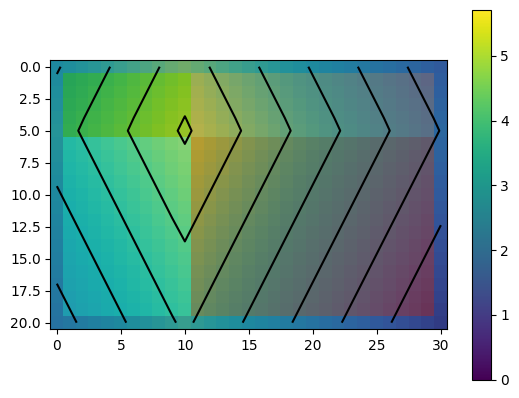

In [22]:
#np.abs(x-nx//3)*slopex
plt.imshow(surface)
colorbar = plt.colorbar()
plt.contour(surface, colors="k")
plt.imshow(mask, cmap="tab10", alpha=0.5)


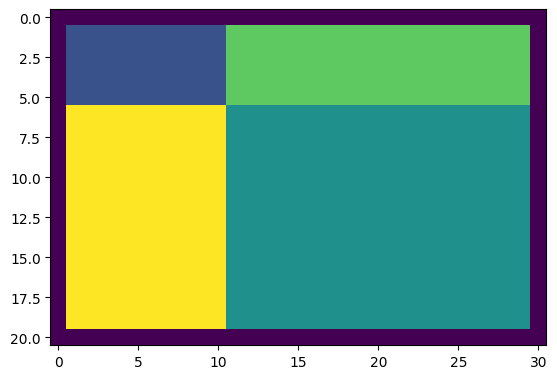

In [23]:
plt.imshow(mask)